In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('fraud.csv')
print(f"Dataset charge : {df.shape[0]} lines and {df.shape[1]} columns.")

Dataset charge : 6362620 lines and 11 columns.


In [2]:
# 1. Vérification des valeurs manquantes
print("- Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 2. Vérification des doublons
print("\n- Nombre de lignes dupliquées :")
print(df.duplicated().sum())

# 3. Suppression des colonnes inutiles (Identifiants et colonnes redondantes)
# 'nameOrig' et 'nameDest' sont des identifiants uniques (string) inutilisables tels quels.
# 'isFlaggedFraud' est une règle simple pré-calculée, on veut que notre modèle apprenne par lui-même.
colonnes_a_supprimer = ['nameOrig', 'nameDest', 'isFlaggedFraud']

# On crée une copie propre pour ne pas modifier l'original par erreur
df_clean = df.drop(columns=colonnes_a_supprimer)

print(f"\n- Colonnes supprimées : {colonnes_a_supprimer}")
print(f"- Taille du dataset après nettoyage : {df_clean.shape}")

# 4. Aperçu rapide
df_clean.head()

- Nombre de valeurs manquantes par colonne :
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

- Nombre de lignes dupliquées :
0

- Colonnes supprimées : ['nameOrig', 'nameDest', 'isFlaggedFraud']
- Taille du dataset après nettoyage : (6362620, 8)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [3]:
import duckdb

# On crée une connexion DuckDB en mémoire
con = duckdb.connect()

# 1. Vérification des valeurs manquantes
# On compare le compte total avec le compte de chaque colonne
# Heureusement, DuckDB reconnaît automatiquement le DataFrame Pandas comme une table !
query_nulls = """
SELECT 
    COUNT(*) AS total_lignes,
    COUNT(*) - COUNT(step) AS null_step,
    COUNT(*) - COUNT(type) AS null_type,
    COUNT(*) - COUNT(amount) AS null_amount,
    COUNT(*) - COUNT(isFraud) AS null_isFraud
FROM df
"""

# 2. Vérification des doublons
# On groupe par toutes les colonnes et on cherche les groupes > 1
query_duplicates = """
SELECT COUNT(*) as nb_doublons 
FROM (
    SELECT step, type, amount, nameOrig, nameDest, oldbalanceOrg, newbalanceOrig 
    FROM df 
    GROUP BY ALL 
    HAVING COUNT(*) > 1
)
"""

print("- Nombre de valeurs manquantes via SQL :")
print(con.execute(query_nulls).df())
print("\n- Nombre de doublons via SQL :")
print(con.execute(query_duplicates).df())

# 3. Création de df_clean en supprimant les colonnes inutiles via SQL
# On sélectionne explicitement les colonnes à garder (on ignore nameOrig, nameDest, isFlaggedFraud)
query_clean = """
SELECT 
    step,
    type, 
    amount, 
    oldbalanceOrg, 
    newbalanceOrig, 
    oldbalanceDest, 
    newbalanceDest, 
    isFraud
FROM df
"""

df_clean = con.execute(query_clean).df()

print(f"\n- Nettoyage terminé via SQL. Taille de df_clean : {df_clean.shape}")

- Nombre de valeurs manquantes via SQL :
   total_lignes  null_step  null_type  null_amount  null_isFraud
0       6362620          0          0            0             0

- Nombre de doublons via SQL :
   nb_doublons
0            0

- Nettoyage terminé via SQL. Taille de df_clean : (6362620, 8)


In [4]:
# On compte le nombre de fraudes pour chaque type de transaction
fraud_by_type = df_clean.groupby('type')['isFraud'].value_counts()

print("- Répartition des fraudes par type :")
print(fraud_by_type)

# Pour y voir plus clair, affichons uniquement les types qui contiennent des fraudes
frauds_only = df_clean[df_clean['isFraud'] == 1]
print("\n- Types de transactions où il y a réellement de la fraude :")
print(frauds_only['type'].unique())

- Répartition des fraudes par type :
type      isFraud
CASH_IN   0          1399284
CASH_OUT  0          2233384
          1             4116
DEBIT     0            41432
PAYMENT   0          2151495
TRANSFER  0           528812
          1             4097
Name: count, dtype: int64

- Types de transactions où il y a réellement de la fraude :
['TRANSFER' 'CASH_OUT']


In [5]:
# Analyse de la répartition de la fraude par type de transaction
query_analysis = """
SELECT 
    type, 
    COUNT(*) as total_trans,
    SUM(isFraud) as nb_fraudes,
    ROUND((SUM(isFraud) * 100.0 / COUNT(*)), 4) as taux_fraude_pourcentage
FROM df_clean
GROUP BY type
ORDER BY nb_fraudes DESC
"""

df_analysis_sql = con.execute(query_analysis).df()

print("- Analyse des fraudes par type via SQL :")
print(df_analysis_sql)

- Analyse des fraudes par type via SQL :
       type  total_trans  nb_fraudes  taux_fraude_pourcentage
0  CASH_OUT      2237500      4116.0                   0.1840
1  TRANSFER       532909      4097.0                   0.7688
2   CASH_IN      1399284         0.0                   0.0000
3   PAYMENT      2151495         0.0                   0.0000
4     DEBIT        41432         0.0                   0.0000


Nouvelle taille du dataset : (2770409, 8)


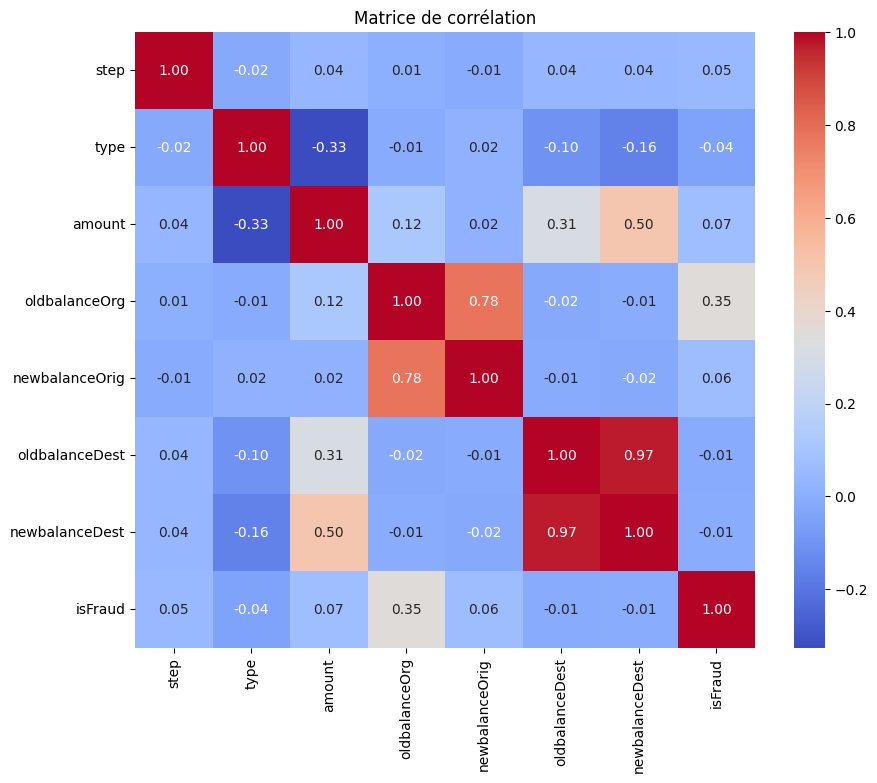

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
2,1,0,181.00,181.0,0.0,0.0,0.00,1
3,1,1,181.00,181.0,0.0,21182.0,0.00,1
15,1,1,229133.94,15325.0,0.0,5083.0,51513.44,0
19,1,0,215310.30,705.0,0.0,22425.0,0.00,0
24,1,0,311685.89,10835.0,0.0,6267.0,2719172.89,0


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# À cause d'une future mise à jour de Pandas, on dit à Pandas d'accepter le nouveau comportement silencieusement
pd.set_option('future.no_silent_downcasting', True)

# 1. On ne garde que les transactions pertinentes (TRANSFER et CASH_OUT)
# On utilise .copy() pour éviter les avertissements de Pandas
df_model = df_clean.loc[df_clean['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Nouvelle taille du dataset : {df_model.shape}")

# 2. Encodage de la variable 'type' (Label Encoding)
# TRANSFER devient 0, CASH_OUT devient 1
df_model['type'] = df_model['type'].replace({'TRANSFER': 0, 'CASH_OUT': 1})

# 3. Vérification des corrélations
# C'est important pour voir si des variables disent la même chose (ex: oldBalance et newBalance)
plt.figure(figsize=(10, 8))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

# Aperçu des données prêtes
df_model.head()

In [7]:
# On exécute la requête SQL directement sur l'objet 'df_clean'
query = """
SELECT 
    step,
    CASE WHEN type = 'TRANSFER' THEN 0 ELSE 1 END AS type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    isFraud
FROM df_clean
WHERE type IN ('TRANSFER', 'CASH_OUT')
"""

df_model = con.execute(query).df()

print("- Résultat via SQL :")
print(df_model.head())
print(f"\n- Nouvelle taille : {df_model.shape}")

- Résultat via SQL :
   step  type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     0     181.00          181.0             0.0             0.0   
1     1     1     181.00          181.0             0.0         21182.0   
2     1     1  229133.94        15325.0             0.0          5083.0   
3     1     0  215310.30          705.0             0.0         22425.0   
4     1     0  311685.89        10835.0             0.0          6267.0   

   newbalanceDest  isFraud  
0            0.00        1  
1            0.00        1  
2        51513.44        0  
3            0.00        0  
4      2719172.89        0  

- Nouvelle taille : (2770409, 8)


In [8]:
from sklearn.model_selection import train_test_split

# 1. Définition des Features (X) et de la Cible (y)
# On enlève 'isFraud' (la réponse) et 'step' (le temps, souvent moins pertinent pour ce modèle simple)
X = df_model.drop(columns=['isFraud', 'step', 'type'])
y = df_model['isFraud']

# 2. Division des données (80% Train, 20% Test)
# stratify=y garantit la même proportion de fraude dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"- Taille du set d'entraînement : {X_train.shape}")
print(f"- Taille du set de test : {X_test.shape}")

print(f"\n- Nombre de fraudes dans le TRAIN : {y_train.sum()}")
print(f"- Nombre de fraudes dans le TEST  : {y_test.sum()}")

- Taille du set d'entraînement : (2216327, 5)
- Taille du set de test : (554082, 5)

- Nombre de fraudes dans le TRAIN : 6570
- Nombre de fraudes dans le TEST  : 1643


In [9]:
# Calcul de l'erreur de balance pour l'origine et la destination
# Idée : Si le calcul (Old - Amount) ne donne pas New, il se passe quelque chose de louche.
df_model['errorBalanceOrig'] = df_model['oldbalanceOrg'] - df_model['amount'] - df_model['newbalanceOrig']
df_model['errorBalanceDest'] = df_model['oldbalanceDest'] + df_model['amount'] - df_model['newbalanceDest']

# On refait le split avec ces nouvelles variables
X = df_model.drop(columns=['isFraud', 'step', 'type'])
y = df_model['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("- Nouvelles colonnes créées : errorBalanceOrig, errorBalanceDest")
print(f"- Nombre de colonnes pour le modèle : {X_train.shape[1]}")

- Nouvelles colonnes créées : errorBalanceOrig, errorBalanceDest
- Nombre de colonnes pour le modèle : 7


In [11]:
# On applique les calculs de balance sur le DataFrame généré à l'étape 3
query_features = """
SELECT 
    *,
    -- Calcul de l'erreur sur le compte d'origine
    (oldbalanceOrg - amount - newbalanceOrig) AS errorBalanceOrig,
    -- Calcul de l'erreur sur le compte de destination
    (oldbalanceDest + amount - newbalanceDest) AS errorBalanceDest
FROM df_model
"""

df_final_sql = con.execute(query_features).df()

# On refait le split avec ces nouvelles variables
X = df_final_sql.drop(columns=['isFraud', 'step', 'type'])
y = df_final_sql['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("- Nouvelles colonnes créées : errorBalanceOrig, errorBalanceDest")
print("- Vérification de l'erreur de balance via SQL :")
# Affichage des premières lignes pour vérifier les calculs
print(df_final_sql[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'errorBalanceOrig']].head())
print(df_final_sql[['amount', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest']].head())
print(f"\n- Taille finale du dataset prêt pour le ML : {df_final_sql.shape}")

- Nouvelles colonnes créées : errorBalanceOrig, errorBalanceDest
- Vérification de l'erreur de balance via SQL :
      amount  oldbalanceOrg  newbalanceOrig  errorBalanceOrig
0     181.00          181.0             0.0              0.00
1     181.00          181.0             0.0              0.00
2  229133.94        15325.0             0.0        -213808.94
3  215310.30          705.0             0.0        -214605.30
4  311685.89        10835.0             0.0        -300850.89
      amount  oldbalanceDest  newbalanceDest  errorBalanceDest
0     181.00             0.0            0.00             181.0
1     181.00         21182.0            0.00           21363.0
2  229133.94          5083.0        51513.44          182703.5
3  215310.30         22425.0            0.00          237735.3
4  311685.89          6267.0      2719172.89        -2401220.0

- Taille finale du dataset prêt pour le ML : (2770409, 12)


Entraînement du modèle en cours...
Génération des prédictions...

- Matrice de Confusion :


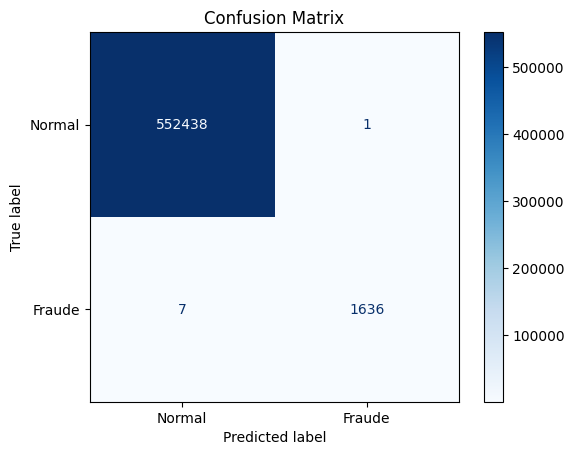


-  Rapport de Classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Création du modèle
# n_jobs=-1 permet d'utiliser tous les coeurs de ton processeur pour aller plus vite
# class_weight='balanced' donne plus d'importance aux fraudes (classe minoritaire)
rf_model = RandomForestClassifier(n_estimators=50, 
                                  random_state=42, 
                                  class_weight='balanced', 
                                  n_jobs=-1)

print("Entraînement du modèle en cours...")
rf_model.fit(X_train, y_train)

# 2. Prédictions sur le test set
print("Génération des prédictions...")
y_pred = rf_model.predict(X_test)

# 3. Évaluation visuelle (Matrice de Confusion)
print("\n- Matrice de Confusion :")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 4. Rapport détaillé
print("\n-  Rapport de Classification :")
print(classification_report(y_test, y_pred))

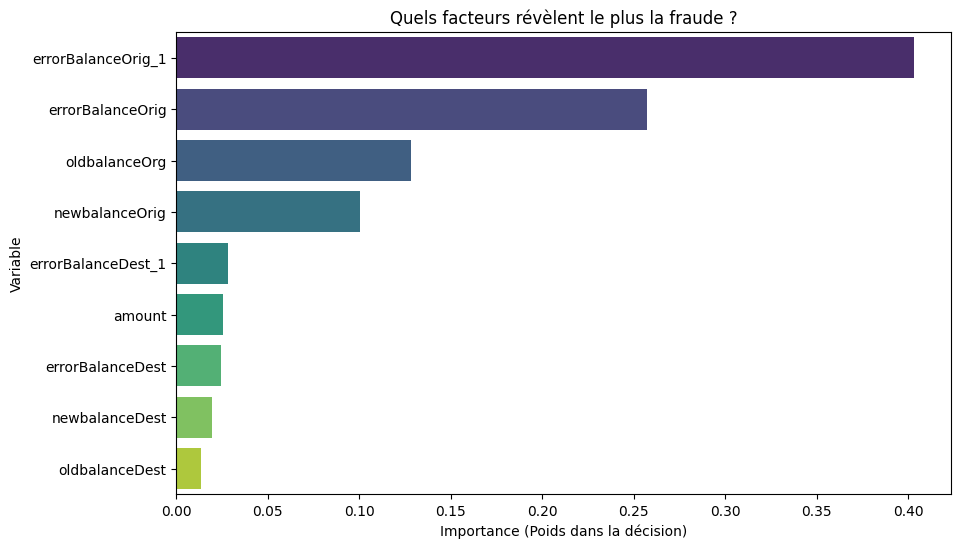

              Feature  Importance
7  errorBalanceOrig_1    0.403507
5    errorBalanceOrig    0.257049
1       oldbalanceOrg    0.128412
2      newbalanceOrig    0.100353
8  errorBalanceDest_1    0.027970
0              amount    0.025246
6    errorBalanceDest    0.024251
4      newbalanceDest    0.019666
3      oldbalanceDest    0.013546


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On récupère l'importance de chaque variable calculée par le Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. On crée un tableau pour trier les résultats
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title("Quels facteurs révèlent le plus la fraude ?")
plt.xlabel("Importance (Poids dans la décision)")
plt.ylabel("Variable")
plt.show()

# Affichage des valeurs exactes
print(feature_importance_df)

In [14]:
import joblib
import pandas as pd

# --- 1. Sauvegarde du modèle (Sérialisation) ---
# On sauvegarde le modèle entraîné pour pouvoir le déployer ultérieurement (API, Application Web) sans avoir à relancer tout l'entraînement.
filename = 'fraud_detection_model.pkl'
joblib.dump(rf_model, filename)

print(f"Modèle sauvegardé avec succès : {filename}")

# --- 2. Simulation d'une détection en temps réel (Inférence) ---
# Simulation : Le système reçoit une nouvelle transaction suspecte.
# Nous chargeons le modèle sauvegardé pour effectuer une prédiction.

loaded_model = joblib.load(filename)

Modèle sauvegardé avec succès : fraud_detection_model.pkl


In [15]:
def preprocess_input(input_data):
    df = pd.DataFrame(input_data)

    # Create error balance features
    df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
    df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

    # Create binary indicator features (REQUIRED by model)
    df['errorBalanceOrig_1'] = (df['errorBalanceOrig'] != 0).astype(int)
    df['errorBalanceDest_1'] = (df['errorBalanceDest'] != 0).astype(int)

    return df

# --- 3. Input Transaction (Test Case) ---
input_data = {
    'amount': [181.0],
    'oldbalanceOrg': [181.0],
    'newbalanceOrig': [0.0],
    'oldbalanceDest': [21182.0],
    'newbalanceDest': [0.0]
}

# --- 4. Apply Preprocessing ---
transaction_df = preprocess_input(input_data)

# --- 5. Ensure Correct Feature Order (CRITICAL) ---
features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig', 
    'oldbalanceDest', 'newbalanceDest', 
    'errorBalanceOrig', 'errorBalanceDest',
    'errorBalanceOrig_1', 'errorBalanceDest_1'
]

transaction_df = transaction_df[features]

# --- 6. Prediction ---
prediction = loaded_model.predict(transaction_df)
probability = loaded_model.predict_proba(transaction_df)[0][1]

# --- 7. Output Result ---
print("\n--- Fraud Detection Result ---")
if prediction[0] == 1:
    print(f"🚨 FRAUD DETECTED (Probability: {probability:.2%})")
    print("Recommended Action: Block transaction and alert security team.")
else:
    print(f"✅ Normal Transaction (Fraud Probability: {probability:.2%})")


--- Fraud Detection Result ---
🚨 FRAUD DETECTED (Probability: 100.00%)
Recommended Action: Block transaction and alert security team.


In [16]:
print(loaded_model.feature_names_in_)

['amount' 'oldbalanceOrg' 'newbalanceOrig' 'oldbalanceDest'
 'newbalanceDest' 'errorBalanceOrig' 'errorBalanceDest'
 'errorBalanceOrig_1' 'errorBalanceDest_1']
